In [186]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [187]:
df = pd.read_csv("housing.csv")

In [188]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [189]:
df.rename(
    columns={
        "nousing_median_age": "age",
        "total_rooms": "rooms",
        "median_income": "income",
        'median_house_value': 'target'
    }, inplace=True
)

In [190]:
df

,longitude,latitude,housing_median_age,rooms,total_bedrooms,population,households,income,target,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [191]:
df.head()

,longitude,latitude,housing_median_age,rooms,total_bedrooms,population,households,income,target,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [192]:
df.isnull()

,longitude,latitude,housing_median_age,rooms,total_bedrooms,population,households,income,target,ocean_proximity
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
20635,False,False,False,False,False,False,False,False,False,False
20636,False,False,False,False,False,False,False,False,False,False
20637,False,False,False,False,False,False,False,False,False,False
20638,False,False,False,False,False,False,False,False,False,False


In [193]:
df.describe()

,longitude,latitude,housing_median_age,rooms,total_bedrooms,population,households,income,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [194]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   rooms               20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   income              20640 non-null  float64
 8   target              20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [195]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
20635    False
20636    False
20637    False
20638    False
20639    False
Length: 20640, dtype: bool

In [196]:
df.drop_duplicates(inplace=True)

In [197]:
df

,longitude,latitude,housing_median_age,rooms,total_bedrooms,population,households,income,target,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [198]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'rooms',
       'total_bedrooms', 'population', 'households', 'income', 'target',
       'ocean_proximity'],
      dtype='str')

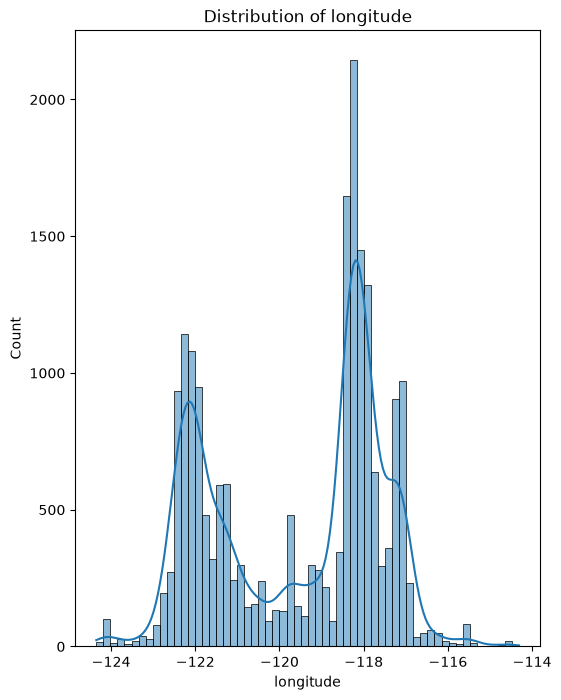

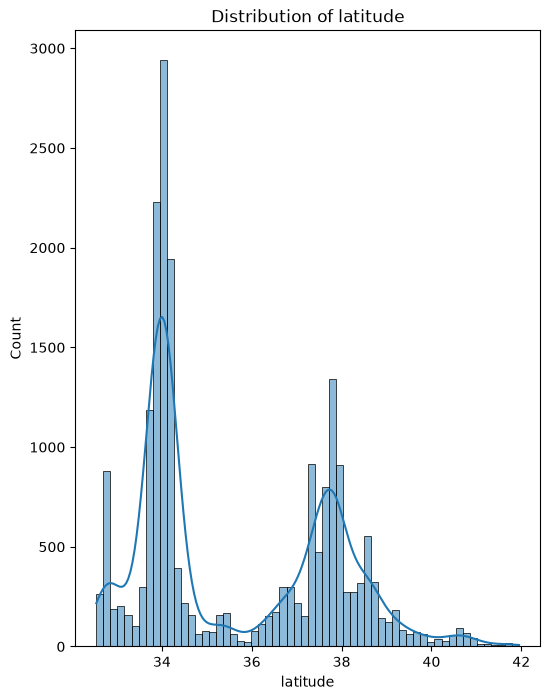

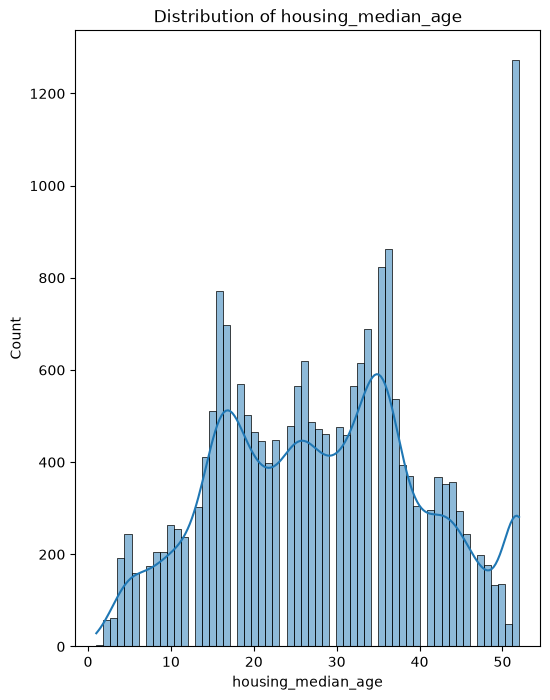

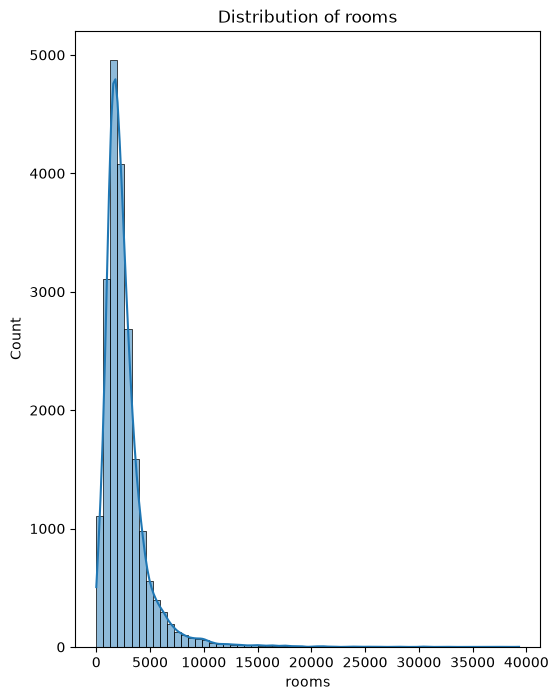

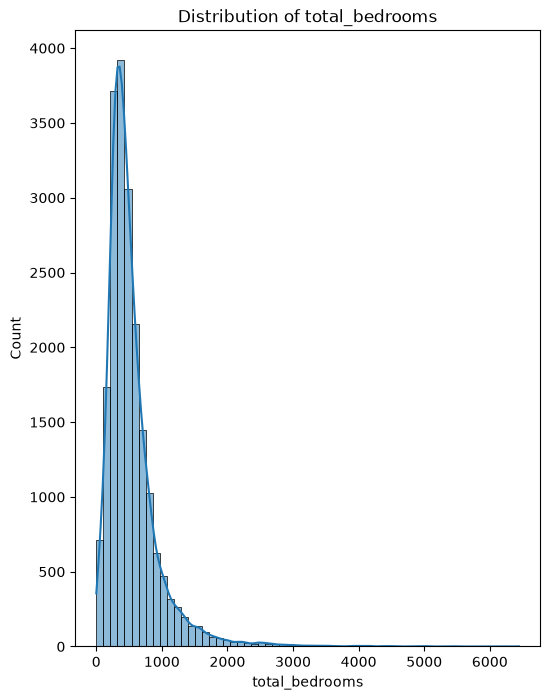

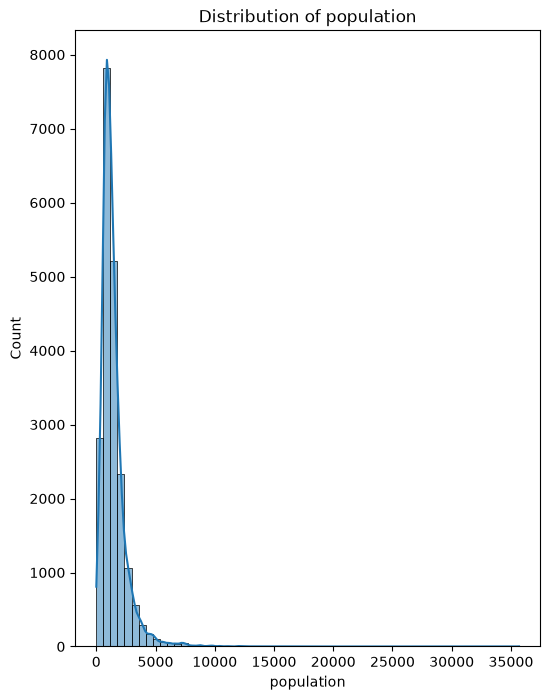

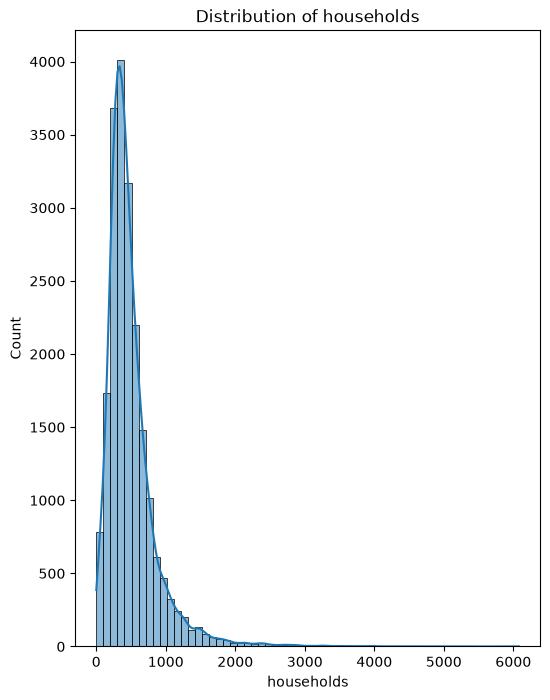

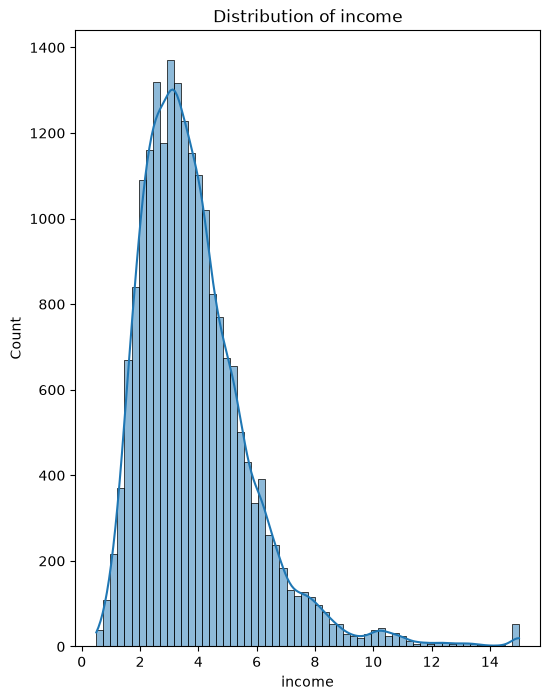

In [199]:
numerical_cols = ["longitude","latitude", "housing_median_age", "rooms", "total_bedrooms", "population", "households", "income"]

for cols in numerical_cols:
    plt.figure(figsize=(6, 8))
    sns.histplot(df[cols], kde=True, bins = 60)
    plt.title(f"Distribution of {cols}")
    plt.show()

<Axes: xlabel='target'>

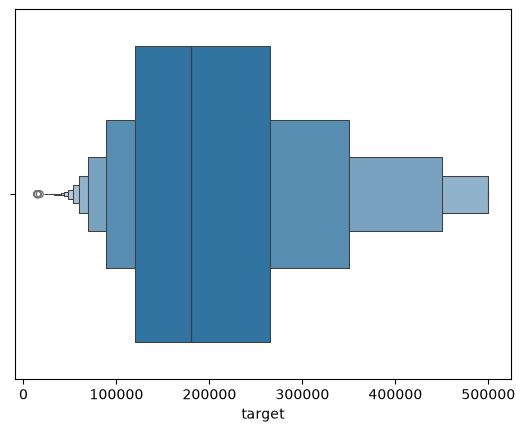

In [200]:
sns.boxenplot(x = df["target"])

<Axes: >

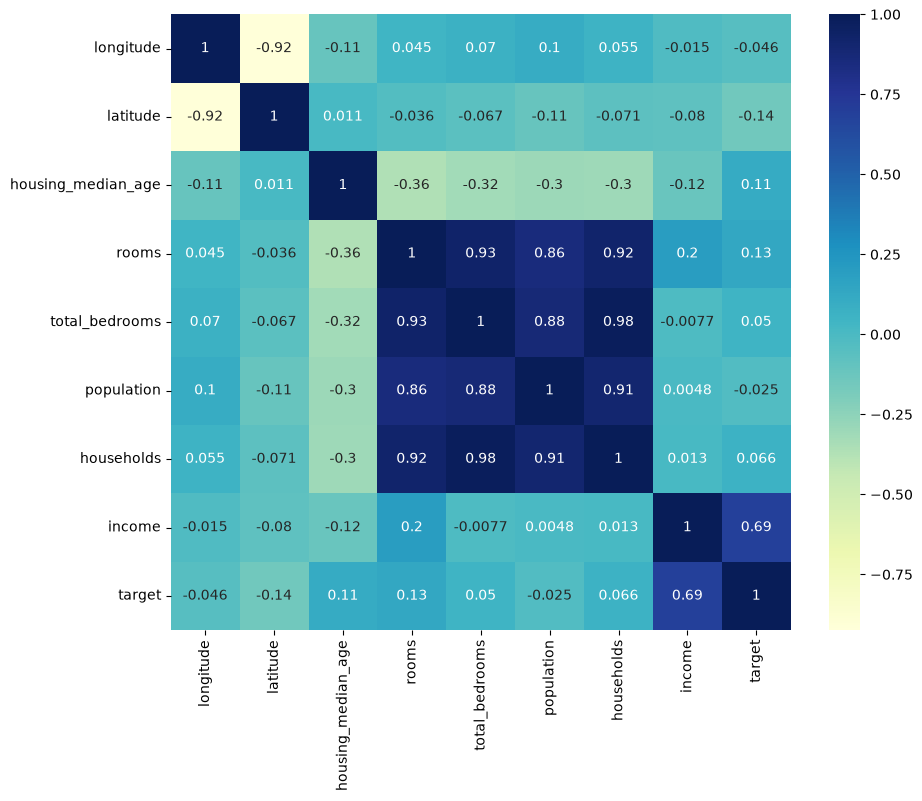

In [201]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [202]:
df

,longitude,latitude,housing_median_age,rooms,total_bedrooms,population,households,income,target,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [203]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [204]:
df["ocean_proximity"].isnull().sum()

np.int64(0)

In [205]:
df = pd.get_dummies(
    df,
    columns = ["ocean_proximity"],
    dtype = int,
    drop_first = True
)

In [206]:
df

,longitude,latitude,housing_median_age,rooms,total_bedrooms,population,households,income,target,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,1,0,0,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,1,0,0,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,1,0,0,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,1,0,0,0


In [207]:
cols = ["longitude", "latitude", "housing_median_age", "rooms", "total_bedrooms", "population", "households", "income"]

scaler = StandardScaler()

df[cols] = scaler.fit_transform(df[cols])
df

,longitude,latitude,housing_median_age,rooms,total_bedrooms,population,households,income,target,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,-0.804819,-0.970325,-0.974429,-0.977033,2.344766,452600.0,0,0,1,0
1,-1.322844,1.043185,-0.607019,2.045890,1.348276,0.861439,1.669961,2.332238,358500.0,0,0,1,0
2,-1.332827,1.038503,1.856182,-0.535746,-0.825561,-0.820777,-0.843637,1.782699,352100.0,0,0,1,0
3,-1.337818,1.038503,1.856182,-0.624215,-0.718768,-0.766028,-0.733781,0.932968,341300.0,0,0,1,0
4,-1.337818,1.038503,1.856182,-0.462404,-0.611974,-0.759847,-0.629157,-0.012881,342200.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-0.444985,-0.388895,-0.512592,-0.443449,-1.216128,78100.0,1,0,0,0
20636,-0.818722,1.806329,-0.845393,-0.888704,-0.920488,-0.944405,-1.008420,-0.691593,77100.0,1,0,0,0
20637,-0.823713,1.778237,-0.924851,-0.174995,-0.125472,-0.369537,-0.174042,-1.142593,92300.0,1,0,0,0
20638,-0.873626,1.778237,-0.845393,-0.355600,-0.305834,-0.604429,-0.393753,-1.054583,84700.0,1,0,0,0


In [208]:
df

,longitude,latitude,housing_median_age,rooms,total_bedrooms,population,households,income,target,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-1.327835,1.052548,0.982143,-0.804819,-0.970325,-0.974429,-0.977033,2.344766,452600.0,0,0,1,0
1,-1.322844,1.043185,-0.607019,2.045890,1.348276,0.861439,1.669961,2.332238,358500.0,0,0,1,0
2,-1.332827,1.038503,1.856182,-0.535746,-0.825561,-0.820777,-0.843637,1.782699,352100.0,0,0,1,0
3,-1.337818,1.038503,1.856182,-0.624215,-0.718768,-0.766028,-0.733781,0.932968,341300.0,0,0,1,0
4,-1.337818,1.038503,1.856182,-0.462404,-0.611974,-0.759847,-0.629157,-0.012881,342200.0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-0.758826,1.801647,-0.289187,-0.444985,-0.388895,-0.512592,-0.443449,-1.216128,78100.0,1,0,0,0
20636,-0.818722,1.806329,-0.845393,-0.888704,-0.920488,-0.944405,-1.008420,-0.691593,77100.0,1,0,0,0
20637,-0.823713,1.778237,-0.924851,-0.174995,-0.125472,-0.369537,-0.174042,-1.142593,92300.0,1,0,0,0
20638,-0.873626,1.778237,-0.845393,-0.355600,-0.305834,-0.604429,-0.393753,-1.054583,84700.0,1,0,0,0


In [209]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [210]:
from scipy.stats import pearsonr, chi2_contingency


In [211]:
selected_features = ['longitude', 'latitude', 'housing_median_age', 'rooms',
       'total_bedrooms', 'population', 'households', 'income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']

correlation = {
    feature: pearsonr(df[feature], df['target'])[0] 
    for feature in selected_features
}
correlation_df = pd.DataFrame(
    list(correlation.items()), 
    columns=['Feature', 'Correlation with Target']
)
correlation_df.sort_values(by='Correlation with Target', ascending=False, inplace=True)

In [212]:
correlation_df

,Feature,Correlation with Target
7,income,0.688075
10,ocean_proximity_NEAR BAY,0.160284
11,ocean_proximity_NEAR OCEAN,0.141862
3,rooms,0.134153
2,housing_median_age,0.105623
6,households,0.065843
4,total_bedrooms,0.049457
9,ocean_proximity_ISLAND,0.023416
5,population,-0.024650
0,longitude,-0.045967


In [213]:
selected_features = ['longitude', 'latitude', 'housing_median_age', 'rooms',
       'total_bedrooms', 'population', 'households', 'income']

In [214]:
alpha = 0.05

df["target_bins"] = pd.qcut(df["target"],q = 4, labels = False)
chi2_results = {}

for cols in selected_features:
    contingency_table = pd.crosstab(df[cols], df["target_bins"])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    chi2_results[cols] = {
        "chi2_statistic": chi2,
        "p_value": p,
        "Decision": "Reject Null Hypothesis (keep feature)" if p < alpha else "Fail to Reject Null Hypothesis(drop feature)"
    }


In [215]:
chi2_df = pd.DataFrame.from_dict(chi2_results, orient='index')
chi2_df.sort_values(by='p_value')
chi2_df


,chi2_statistic,p_value,Decision
longitude,13322.073429,0.000000e+00,Reject Null Hypothesis (keep feature)
latitude,11979.144728,0.000000e+00,Reject Null Hypothesis (keep feature)
housing_median_age,864.276128,1.156534e-99,Reject Null Hypothesis (keep feature)
rooms,18167.724458,1.916619e-02,Reject Null Hypothesis (keep feature)
total_bedrooms,6094.761127,1.300605e-03,Reject Null Hypothesis (keep feature)
population,11830.361496,1.339229e-01,Fail to Reject Null Hypothesis(drop feature)
households,5703.904106,6.613171e-03,Reject Null Hypothesis (keep feature)
income,41797.980979,2.129588e-26,Reject Null Hypothesis (keep feature)


In [253]:
final_df = df[['housing_median_age', 'rooms',
       'total_bedrooms', 'income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'] + ['target']]

In [254]:
final_df

,housing_median_age,rooms,total_bedrooms,income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,target
0,0.982143,-0.804819,-0.970325,2.344766,0,0,1,0,452600.0
1,-0.607019,2.045890,1.348276,2.332238,0,0,1,0,358500.0
2,1.856182,-0.535746,-0.825561,1.782699,0,0,1,0,352100.0
3,1.856182,-0.624215,-0.718768,0.932968,0,0,1,0,341300.0
4,1.856182,-0.462404,-0.611974,-0.012881,0,0,1,0,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-0.289187,-0.444985,-0.388895,-1.216128,1,0,0,0,78100.0
20636,-0.845393,-0.888704,-0.920488,-0.691593,1,0,0,0,77100.0
20637,-0.924851,-0.174995,-0.125472,-1.142593,1,0,0,0,92300.0
20638,-0.845393,-0.355600,-0.305834,-1.054583,1,0,0,0,84700.0


In [255]:
X = final_df.drop("target", axis = 1)
y = final_df["target"]

In [256]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [257]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 15272.54,-32974.4 , 42187.12,...,167292.01, 10965.36, 17339.05]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['housing_median_age','rooms','total_bedrooms',..., 'ocean_proximity_ISLAND','ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.238e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [258]:
y_pred = model.predict(X_test)

In [259]:
df.isnull().sum()

longitude                     0
latitude                      0
housing_median_age            0
rooms                         0
total_bedrooms                0
population                    0
households                    0
income                        0
target                        0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
target_bins                   0
dtype: int64

In [260]:
y_pred

array([ 68750.06226926,  89234.39766216, 218126.46542338, ...,
       286707.41249926, 151946.0942207 , 241672.69717699], shape=(6192,))

In [261]:
y_test

20046     47700.0
3024      45800.0
15663    500001.0
20484    218600.0
9814     278000.0
           ...   
17505    237500.0
13512     67300.0
10842    218400.0
16559    119400.0
5786     209800.0
Name: target, Length: 6192, dtype: float64

In [262]:
from sklearn.metrics import mean_squared_error, r2_score

In [263]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

In [264]:
print(f"R-squared: {r2}")
print(f"Mean Squared Error: {mse}")

R-squared: 0.606606479216439
Mean Squared Error: 5163447741.825304
